In [ ]:
import torch
import numpy as np
from torch import nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Dataset, Subset
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import time
import kagglehub

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [ ]:
print("Downloading dataset from Kaggle...")
kaggle_path = kagglehub.dataset_download("emmarex/plantdisease")
path = os.path.join(kaggle_path, "PlantVillage") # Set the path to the correct directory
print(f"Dataset downloaded to: {path}")


Using Colab cache for faster access to the 'plantdisease' dataset.
Dataset downloaded to: /kaggle/input/plantdisease/PlantVillage


Number of total classes: 15
Random class name: Tomato__Target_Spot
Image height: 256
Image width: 256


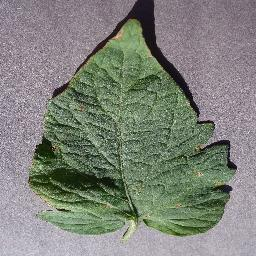

In [ ]:
classes = [name for name in os.listdir(path) if os.path.isdir(os.path.join(path, name))]

class_name = random.choice(classes)
class_path = os.path.join(path, class_name)
img_name = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, img_name)

img = Image.open(img_path)

print(f"Number of total classes: {len(classes)}")
print(f"Random class name: {class_name}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")

img

In [ ]:
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ToTensor()
])

def visualize_transform(img_path, transform):
    img = Image.open(img_path)
    print(f"Original Image type: {type(img)}")
    transformed_img = transform(img)
    print(f"Transformed Image type: {type(transformed_img)}")
    if isinstance(transformed_img, torch.Tensor):
        transformed_img_pil = transforms.ToPILImage()(transformed_img)
    else:
        transformed_img_pil = transformed_img

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(img)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(transformed_img_pil)
    axes[1].set_title("Transformed")
    axes[1].axis("off")

    plt.show()

Original Image type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Transformed Image type: <class 'torch.Tensor'>


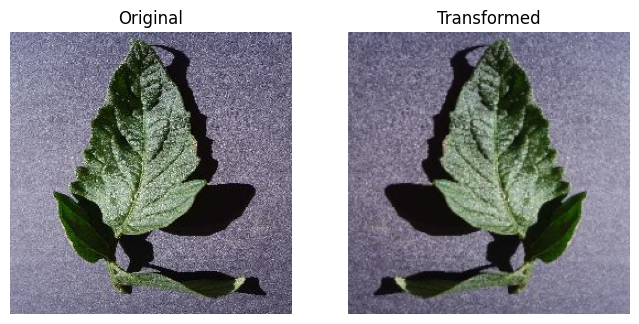

Full dataset size: 20638
Number of Train images: 16510 | Number of Test images: 4128


In [ ]:
class_name = random.choice(classes)
class_path = os.path.join(path, class_name)
img_name = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, img_name)

visualize_transform(img_path, data_transform)

full_dataset = datasets.ImageFolder(root=path, transform=None)
print(f"Full dataset size: {len(full_dataset)}")

class_to_idx = full_dataset.class_to_idx
idx_to_class = {value: key for key, value in class_to_idx.items()}
classes = list(class_to_idx.keys())

targets = [sample[1] for sample in full_dataset.samples]

train_idx, test_idx = train_test_split(
    np.arange(len(targets)),
    test_size=0.2,
    random_state=42,
    stratify=targets
)

print(f"Number of Train images: {len(train_idx)} | Number of Test images: {len(test_idx)}")

temp_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

temp_full = datasets.ImageFolder(root=path, transform=temp_transform)
temp_train = Subset(temp_full, train_idx)

In [ ]:
# def get_mean_std(dataset, batch_size=16, num_workers=2):
#     loader = DataLoader(dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False)
#     rgb_sum = torch.zeros(3)
#     rgb_sumsq = torch.zeros(3)
#     count_pixels = 0

#     print("Calculating mean and std...")
#     for x, _ in tqdm(loader, desc="Calculating mean/std"):
#         b, c, h, w = x.shape
#         count_pixels += b * h * w
#         rgb_sum += x.sum(dim=[0, 2, 3])
#         rgb_sumsq += (x**2).sum(dim=[0, 2, 3])

#     mean = rgb_sum / count_pixels
#     std = torch.sqrt(rgb_sumsq / count_pixels - mean **2)
#     return mean.tolist(), std.tolist()

# mean, std = get_mean_std(temp_train)


In [ ]:
mean = [0.5, 0.5, 0.5]
std = [0.5, 0.5, 0.5]
print(f"Calculated Mean: {mean}")
print(f"Calculated Std: {std}")

Calculated Mean: [0.5, 0.5, 0.5]
Calculated Std: [0.5, 0.5, 0.5]


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

train_data_all = datasets.ImageFolder(root=path, transform=train_transform)
test_data_all = datasets.ImageFolder(root=path, transform=test_transform)

train_set = Subset(train_data_all, train_idx)
test_set = Subset(test_data_all, test_idx)

print(f"Train set size: {len(train_set)} | Test set size: {len(test_set)}")


Train set size: 16510 | Test set size: 4128


In [ ]:
BATCH_SIZE = 16
NUM_WORKERS = 2

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Number of batches in train_loader: {len(train_loader)} | Number of batches in test_loader: {len(test_loader)}")

class SampleCNN(nn.Module):
    def __init__(self, input_shape, output_shape, hidden_units):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x):
        return self.layer(x)

input_shape = 3 * 224 * 224
output_shape = 15
hidden_units = 256

sampleCnn = SampleCNN(input_shape, output_shape, hidden_units).to(device)
print(sampleCnn)


Number of batches in train_loader: 1032 | Number of batches in test_loader: 258
SampleCNN(
  (layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=150528, out_features=256, bias=True)
    (2): Linear(in_features=256, out_features=15, bias=True)
  )
)


In [ ]:

class newCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=128 * 28 * 28, out_features=512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(in_features=512, out_features=num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x


In [ ]:
# Initialize the model, loss function, and optimizer
torch.manual_seed(42)
num_classes = len(classes)
model = newCNN(num_classes=num_classes).to(device)
print(model)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train_step(model, dataloader, loss_fn, optimizer, device):
    """
    Performs a training step with model, dataloader, loss_fn, optimizer, and device
    """
    model.train()
    train_loss, train_acc = 0, 0

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

def test_step(model, dataloader, loss_fn, device):
    """
    Performs a testing step with model, dataloader, loss_fn, and device
    """
    model.eval()
    test_loss, test_acc = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

def train(model, train_dataloader, test_dataloader, optimizer, loss_fn, epochs, device):
    """
    Trains the model for the given number of epochs
    """
    results = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    start_time = time.time()
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           device=device)

        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn,
                                        device=device)

        print(f"Epoch: {epoch+1} | "
              f"train_loss: {train_loss:.4f} | "
              f"train_acc: {train_acc:.4f} | "
              f"test_loss: {test_loss:.4f} | "
              f"test_acc: {test_acc:.4f}")

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    end_time = time.time()
    total_time = end_time - start_time
    print(f"Training time: {total_time:.3f} seconds")

    return results

# Train the model
epochs = 10
print("\n Starting RGB model training")
results = train(model=model,
                train_dataloader=train_loader,
                test_dataloader=test_loader,
                optimizer=optimizer,
                loss_fn=loss_fn,
                epochs=epochs,
                device=device)

print("RGB training completed!")
print(f"RGB Training Results: {results}")


newCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, ou

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.6157 | train_acc: 0.4627 | test_loss: 0.8841 | test_acc: 0.7013
Epoch: 2 | train_loss: 0.9016 | train_acc: 0.7012 | test_loss: 0.6277 | test_acc: 0.7963
Epoch: 3 | train_loss: 0.6542 | train_acc: 0.7808 | test_loss: 0.4437 | test_acc: 0.8537
Epoch: 4 | train_loss: 0.5309 | train_acc: 0.8196 | test_loss: 0.4273 | test_acc: 0.8530
Epoch: 5 | train_loss: 0.4426 | train_acc: 0.8514 | test_loss: 0.3631 | test_acc: 0.8777
Epoch: 6 | train_loss: 0.4038 | train_acc: 0.8661 | test_loss: 0.4068 | test_acc: 0.8636
Epoch: 7 | train_loss: 0.3450 | train_acc: 0.8842 | test_loss: 0.2575 | test_acc: 0.9169
Epoch: 8 | train_loss: 0.3176 | train_acc: 0.8955 | test_loss: 0.4020 | test_acc: 0.8745
Epoch: 9 | train_loss: 0.2826 | train_acc: 0.9070 | test_loss: 0.2111 | test_acc: 0.9300
Epoch: 10 | train_loss: 0.2568 | train_acc: 0.9146 | test_loss: 0.2722 | test_acc: 0.9142
Training time: 1085.869 seconds
RGB training completed!
RGB Training Results: {'train_loss': [1.6157276518354


Starting Grayscale Training 


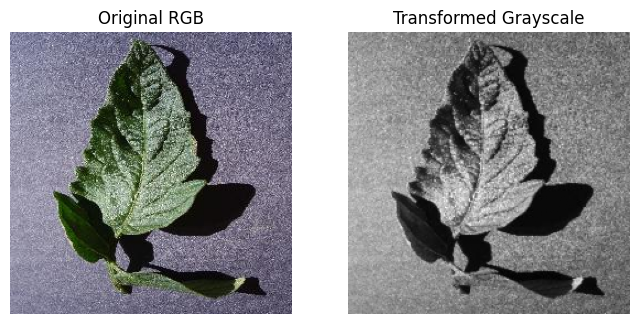

Calculating grayscale mean and std...


Calculating mean/std:   0%|          | 0/1032 [00:00<?, ?it/s]

Calculated Grayscale Mean: [0.4633297324180603]
Calculated Grayscale Std: [0.16820478439331055]

Starting grayscale model training...


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.8234 | train_acc: 0.4089 | test_loss: 1.3522 | test_acc: 0.5337
Epoch: 2 | train_loss: 1.1964 | train_acc: 0.6126 | test_loss: 0.8604 | test_acc: 0.7112
Epoch: 3 | train_loss: 0.9393 | train_acc: 0.6869 | test_loss: 0.7161 | test_acc: 0.7594
Epoch: 4 | train_loss: 0.8187 | train_acc: 0.7306 | test_loss: 0.6856 | test_acc: 0.7708
Epoch: 5 | train_loss: 0.7287 | train_acc: 0.7541 | test_loss: 0.6258 | test_acc: 0.7900
Epoch: 6 | train_loss: 0.6718 | train_acc: 0.7774 | test_loss: 0.5405 | test_acc: 0.8227
Epoch: 7 | train_loss: 0.6108 | train_acc: 0.7945 | test_loss: 0.4823 | test_acc: 0.8423
Epoch: 8 | train_loss: 0.5478 | train_acc: 0.8177 | test_loss: 0.5060 | test_acc: 0.8379
Epoch: 9 | train_loss: 0.5133 | train_acc: 0.8305 | test_loss: 0.4603 | test_acc: 0.8491
Epoch: 10 | train_loss: 0.4797 | train_acc: 0.8381 | test_loss: 0.4324 | test_acc: 0.8571
Training time: 983.081 seconds
Grayscale training completed!
Grayscale Training Results: {'train_loss': [1.82

In [ ]:
#Grayscale Image Conversion and Training

print("\nStarting Grayscale Training ")

# Grayscale Transformation
def visualize_grayscale_transform(img_path, transform):
    img = Image.open(img_path)
    transformed_img = transform(img)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img)
    axes[0].set_title("Original RGB")
    axes[0].axis("off")

    # Grayscale image needs cmap="gray" to display correctly
    axes[1].imshow(transformed_img.squeeze(), cmap="gray")
    axes[1].set_title("Transformed Grayscale")
    axes[1].axis("off")

    plt.show()

# Visualize the grayscale transform on a random image
img_path = os.path.join(class_path, img_name)
grayscale_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

visualize_grayscale_transform(img_path, grayscale_transform)

# Create new datasets and dataloaders for grayscale images
temp_full_gray = datasets.ImageFolder(root=path, transform=transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
]))
temp_train_gray = Subset(temp_full_gray, train_idx)

def get_mean_std_gray(dataset, batch_size=16, num_workers=2):
    loader = DataLoader(dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False)
    sum_pixels = 0
    sumsq_pixels = 0
    count_pixels = 0

    print("Calculating grayscale mean and std...")
    for x, _ in tqdm(loader, desc="Calculating mean/std"):
        b, c, h, w = x.shape
        count_pixels += b * h * w
        sum_pixels += x.sum()
        sumsq_pixels += (x**2).sum()

    mean = sum_pixels / count_pixels
    std = torch.sqrt(sumsq_pixels / count_pixels - mean **2)
    return [mean.item()], [std.item()]

mean_gray, std_gray = get_mean_std_gray(temp_train_gray)
print(f"Calculated Grayscale Mean: {mean_gray}")
print(f"Calculated Grayscale Std: {std_gray}")

train_transform_gray = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_gray, std=std_gray)
])

test_transform_gray = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_gray, std=std_gray)
])

train_data_all_gray = datasets.ImageFolder(root=path, transform=train_transform_gray)
test_data_all_gray = datasets.ImageFolder(root=path, transform=test_transform_gray)

train_set_gray = Subset(train_data_all_gray, train_idx)
test_set_gray = Subset(test_data_all_gray, test_idx)

train_loader_gray = DataLoader(train_set_gray, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader_gray = DataLoader(test_set_gray, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# New CNN model for grayscale images
class newCNN_grayscale(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=128 * 28 * 28, out_features=512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(in_features=512, out_features=num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

# Initialize and train the grayscale model
model_gray = newCNN_grayscale(num_classes=num_classes).to(device)
loss_fn_gray = nn.CrossEntropyLoss()
optimizer_gray = torch.optim.Adam(model_gray.parameters(), lr=0.001)

print("\nStarting grayscale model training...")
results_gray = train(model=model_gray,
                     train_dataloader=train_loader_gray,
                     test_dataloader=test_loader_gray,
                     optimizer=optimizer_gray,
                     loss_fn=loss_fn_gray,
                     epochs=epochs,
                     device=device)

print("Grayscale training completed!")
print(f"Grayscale Training Results: {results_gray}")


In [ ]:
MODEL_PATH = "newCNN_trained_model.pth"

# Save the state dictionary
print(f"\nSaving model to: {MODEL_PATH}")
torch.save(model.state_dict(), MODEL_PATH)
print("Model saved!")


Saving model to: newCNN_trained_model.pth
Model saved!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# Prediction Function
def make_prediction(model, image_path, test_transform, idx_to_class, device):
    """
    Performs a prediction on a single image.

    Args:
        model (torch.nn.Module): The trained model to use for prediction.
        image_path (str): The path to the image file.
        test_transform (torchvision.transforms.Compose): The same transformations
                                                          used for the test set.
        idx_to_class (dict): The dictionary to map class indices to names.
        device (str): The device to run the prediction on ('cuda' or 'cpu').

    Returns:
        tuple: A tuple containing the predicted class name, the predicted index,
               and the raw logits.
    """
    # Put the model in evaluation mode
    model.eval()

    # Load and transform the image
    img = Image.open(image_path).convert('RGB')
    transformed_img = test_transform(img)

    # Add a batch dimension to the image tensor
    transformed_img = transformed_img.unsqueeze(0).to(device)

    # Perform a forward pass with torch.no_grad()
    with torch.no_grad():
        logits = model(transformed_img)

    # Get the predicted class index from the logits
    predicted_index = torch.argmax(logits, dim=1).item()

    # Get the predicted class name
    predicted_class_name = idx_to_class[predicted_index]

    return predicted_class_name, predicted_index, logits

# Choose a random image from the test set for prediction
random_test_idx = random.choice(test_idx)
random_test_path, _ = full_dataset.samples[random_test_idx]
true_class = os.path.basename(os.path.dirname(random_test_path))

# Make the prediction using the trained model
predicted_name, predicted_index, logits = make_prediction(model, random_test_path, test_transform, idx_to_class, device)

print("\n--- Example Prediction ---")
print(f"Path to image: {random_test_path}")
print(f"True class: {true_class}")
print(f"Predicted class: {predicted_name}")
print(f"Predicted index: {predicted_index}")
print(f"Logits for all classes: {logits}")




--- Example Prediction ---
Path to image: /kaggle/input/plantdisease/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/1e924491-cb5f-4843-8f26-de597f552240___YLCV_NREC 2011.JPG
True class: Tomato__Tomato_YellowLeaf__Curl_Virus
Predicted class: Tomato__Tomato_YellowLeaf__Curl_Virus
Predicted index: 12
Logits for all classes: tensor([[ -9.9917, -19.9187, -36.0572, -19.7338, -42.5394, -12.3977,  -4.2591,
          -7.7521,  -0.7175,  -3.5255,  -0.0775, -14.3360,  12.4580,  -9.5763,
         -40.8690]], device='cuda:0')


In [ ]:
from google.colab import files
files.download('newCNN_trained_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
print(os.listdir('.'))

['.config', 'newCNN_trained_model.pth', 'sample_data']
